<a href="https://colab.research.google.com/github/pedromaranhao33/datascience/blob/main/MLESD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Modeling Life Expectancy with Socioeconomic Data**

In this project, we perform statistical modeling using a dataset obtained from the World Health Organization (WHO) Global Health Observatory https://www.who.int/data/gho/data/themes/mortality-and-global-health-estimates/ghe-life-expectancy-and-healthy-life-expectancy. The dataset includes life expectancy and healthy life expectancy measures, along with several socioeconomic indicators. The main objective is to identify which socioeconomic factors are most relevant for predicting life expectancy. The results aim to provide insights that may support public health policy formulation and promote healthier lifestyle interventions.

## Loading libraries

In [110]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

## Loading and understanding data

In [111]:
# loading data

FILE_ID = "1K5pYN4xJcw4nbu8D9VhjcN131609_2dN"

url = f"https://drive.google.com/uc?id={FILE_ID}"

df = pd.read_csv(url)

In [112]:
# Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [113]:
# Data sample view

df.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1676,Mauritius,2006,Developing,71.8,165.0,0,3.73,502.384495,97.0,3,...,98.0,4.38,97.0,0.1,5695.969327,1233996.0,7.6,7.5,0.713,13.4
2839,Uzbekistan,2002,Developing,67.1,186.0,27,1.47,24.994387,62.0,25,...,99.0,5.44,99.0,0.2,383.349500,2527185.0,3.3,3.3,0.600,11.0
1372,Kenya,2005,Developing,54.1,412.0,70,1.82,39.556775,76.0,153,...,7.0,4.36,76.0,11.6,519.799935,3648288.0,8.6,8.5,0.474,9.6
2122,Romania,2012,Developed,74.4,138.0,2,9.58,1078.358105,96.0,7450,...,92.0,5.48,91.0,0.1,8558.397660,25835.0,2.8,3.0,0.797,15.3
1921,Norway,2004,Developed,79.8,77.0,0,6.22,1009.825011,NaN,7,...,92.0,9.44,92.0,0.1,5757.269160,459191.0,0.8,0.7,0.924,17.5
652,Croatia,2004,Developed,75.4,114.0,0,13.11,1116.396502,NaN,54,...,96.0,6.56,96.0,0.1,9365.742468,4439.0,1.9,1.9,0.771,13.3
2758,United Arab Emirates,2003,Developing,74.9,98.0,1,1.74,277.181833,92.0,42,...,94.0,2.65,94.0,0.1,3323.523180,NaN,5.2,5.0,0.808,12.3
2095,Republic of Korea,2007,Developing,79.8,77.0,2,9.05,0.000000,91.0,194,...,91.0,5.99,91.0,0.1,NaN,NaN,1.5,1.0,NaN,NaN
1069,Guatemala,2004,Developing,69.6,21.0,15,2.40,288.401626,NaN,0,...,88.0,6.77,87.0,0.4,1872.737830,12796925.0,1.4,1.4,0.564,9.3
1998,Paraguay,2008,Developing,72.7,157.0,3,6.14,34.739246,87.0,0,...,85.0,7.60,89.0,0.1,359.992184,647117.0,2.1,2.1,0.654,11.9


## First data wrangling

In [114]:
# Columns

df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', ' Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [115]:
# First, we clean the column names by trimming whitespace and add underscore in the space between words. Before that, we remove some variables due to unclear
# or insufficient descriptions in the data source. Therefore, the following columns are excluded from the analysis:
# 1) percentage expenditure, 2) under-five deaths, and 3) income composition of resources.

df = pd.DataFrame({'country': df['Country'],
                   'life_expectancy': df['Life expectancy '],
                   'year': df['Year'],
                   'status': df['Status'],
                   'adult_mortality': df['Adult Mortality'],
                   'inf_death': df['infant deaths'],
                   'alcohol': df['Alcohol'],
                   'hepatitisB': df['Hepatitis B'],
                   'measles': df['Measles '],
                   'bmi': df[' BMI '],
                   'polio': df['Polio'],
                   'diphtheria': df['Diphtheria '],
                   'hiv': df[' HIV/AIDS'],
                   'gdp': df['GDP'],
                   'total_expenditure': df['Total expenditure'],
                   'thinness_till19': df[' thinness  1-19 years'],
                   'thinness_till9': df[' thinness 5-9 years'],
                   'school': df['Schooling'],
                   'population': df[' Population']})

In [116]:
# Column types and shapes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            2938 non-null   object 
 1   life_expectancy    2928 non-null   float64
 2   year               2938 non-null   int64  
 3   status             2938 non-null   object 
 4   adult_mortality    2928 non-null   float64
 5   inf_death          2938 non-null   int64  
 6   alcohol            2744 non-null   float64
 7   hepatitisB         2385 non-null   float64
 8   measles            2938 non-null   int64  
 9   bmi                2904 non-null   float64
 10  polio              2919 non-null   float64
 11  diphtheria         2919 non-null   float64
 12  hiv                2938 non-null   float64
 13  gdp                2490 non-null   float64
 14  total_expenditure  2712 non-null   float64
 15  thinness_till19    2904 non-null   float64
 16  thinness_till9     2904 

In [117]:
# First rows of our dataframe

df.head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
0,Afghanistan,65.0,2015,Developing,263.0,62,0.01,65.0,1154,19.1,6.0,65.0,0.1,584.259210,8.16,17.2,17.3,10.1,33736494.0
1,Afghanistan,59.9,2014,Developing,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0
2,Afghanistan,59.9,2013,Developing,268.0,66,0.01,64.0,430,18.1,62.0,64.0,0.1,631.744976,8.13,17.7,17.7,9.9,31731688.0
3,Afghanistan,59.5,2012,Developing,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0
4,Afghanistan,59.2,2011,Developing,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0


## Exploratory Data Analysis


In [118]:
# Create a data dictionary describing each variable.

df_dict = {
    "country": "Country of data origin.",
    "life_expectancy": "Life expectancy at birth, measured in years.",
    "year": "Year of data collection.",
    "status": "Country development status ('Developing' or 'Developed').",
    "adult_mortality": "Adult mortality rate between ages 15 and 60 per 1,000 inhabitants.",
    "inf_death": "Under-five mortality rate (per 1,000 live births).",
    "alcohol": "Per capita alcohol consumption (litres of pure alcohol per year).",
    "hepatitisB": "Hepatitis B vaccination coverage among 1-year-old children (%).",
    "measles": "Number of measles cases per 1,000 inhabitants.",
    "bmi": "Mean Body Mass Index in the adult population.",
    "polio": "Polio vaccination coverage among 1-year-old children (%).",
    "diphtheria": "Diphtheria tetanus toxoid and pertussis vaccination coverage among 1-year-old children (%).",
    "hiv": "HIV prevalence in the adult population (%).",
    "gdp": "Gross Domestic Product (GDP) per capita (US$).",
    "total_expenditure": "Total health expenditure as a percentage of GDP.",
    "thinness_till19": "Prevalence of thinness among children and adolescents aged 10 to 19 (%).",
    "thinness_till9": "Prevalence of thinness among children aged 5 to 9 (%).",
    "school": "Average years of schooling.",
    "population": "Total population of the country."
}

In [119]:
# Each variable is now accompanied by dictionary description explaining its meaning and usage.

df_dict['life_expectancy']

'Life expectancy at birth, measured in years.'

<Axes: >

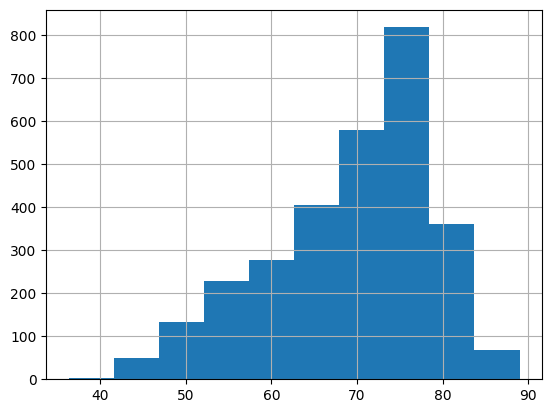

In [120]:
# Histogram of our target variable (quantitative)

df['life_expectancy'].hist()

In [121]:
# Statistical summary (numeric variables)

df.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2928.000000,2938.000000,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2919.000000,2938.000000,2490.000000,2712.00000,2904.000000,2904.000000,2775.000000,2.286000e+03
mean,69.224932,2007.518720,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,82.324084,1.742103,7483.158469,5.93819,4.839704,4.870317,11.992793,1.275338e+07
std,9.523867,4.613841,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,23.716912,5.077785,14270.169342,2.49832,4.420195,4.508882,3.358920,6.101210e+07
min,36.300000,2000.000000,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,2.000000,0.100000,1.681350,0.37000,0.100000,0.100000,0.000000,3.400000e+01
25%,63.100000,2004.000000,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,78.000000,0.100000,463.935626,4.26000,1.600000,1.500000,10.100000,1.957932e+05
50%,72.100000,2008.000000,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,93.000000,0.100000,1766.947595,5.75500,3.300000,3.300000,12.300000,1.386542e+06
75%,75.700000,2012.000000,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,97.000000,0.800000,5910.806335,7.49250,7.200000,7.200000,14.300000,7.420359e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.870000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.600000,119172.741800,17.60000,27.700000,28.600000,20.700000,1.293859e+09


In [122]:
# Statistical summary (categorical variables)

df.describe(include=['object'])

,country,status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [123]:
# Statistical summary of all variables

df.describe(include = 'all')

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2938,2928.000000,2938.000000,2938,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2919.000000,2938.000000,2490.000000,2712.00000,2904.000000,2904.000000,2775.000000,2.286000e+03
unique,193,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,Developing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,NaN,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,69.224932,2007.518720,NaN,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,82.324084,1.742103,7483.158469,5.93819,4.839704,4.870317,11.992793,1.275338e+07
std,NaN,9.523867,4.613841,NaN,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,23.716912,5.077785,14270.169342,2.49832,4.420195,4.508882,3.358920,6.101210e+07
min,NaN,36.300000,2000.000000,NaN,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,2.000000,0.100000,1.681350,0.37000,0.100000,0.100000,0.000000,3.400000e+01
25%,NaN,63.100000,2004.000000,NaN,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,78.000000,0.100000,463.935626,4.26000,1.600000,1.500000,10.100000,1.957932e+05
50%,NaN,72.100000,2008.000000,NaN,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,93.000000,0.100000,1766.947595,5.75500,3.300000,3.300000,12.300000,1.386542e+06
75%,NaN,75.700000,2012.000000,NaN,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,97.000000,0.800000,5910.806335,7.49250,7.200000,7.200000,14.300000,7.420359e+06


In [124]:
# Function to plot the relationship between the target variable and other features

def get_pairs(data, target, features, n):

    # Row group with 3 (n) plots by row
    row_group = [features[i:i+n] for i in range(0, len(features), n)]

    # Loop through each row group to create pair plots
    for row in row_group:
        plot = sns.pairplot(x_vars = row, y_vars = target, data = data, kind = "reg", height = 3)

    return

In [125]:
# Target variable

target = ['life_expectancy']

In [126]:
# Selected features

features = ['population', 'hepatitisB', 'gdp', 'total_expenditure', 'alcohol', 'school']

In [127]:
# Variable description

df_dict['population']

'Total population of the country.'

In [128]:
# Variable definition

df_dict['hepatitisB']

'Hepatitis B vaccination coverage among 1-year-old children (%).'

In [129]:
# Variable definition

df_dict['gdp']

'Gross Domestic Product (GDP) per capita (US$).'

In [130]:
# Variable definition

df_dict['total_expenditure']

'Total health expenditure as a percentage of GDP.'

In [131]:
# Variable definition

df_dict['alcohol']

'Per capita alcohol consumption (litres of pure alcohol per year).'

In [132]:
# Variable definition

df_dict['school']

'Average years of schooling.'

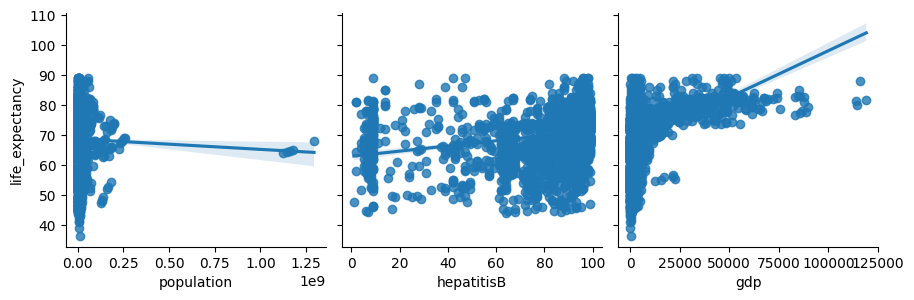

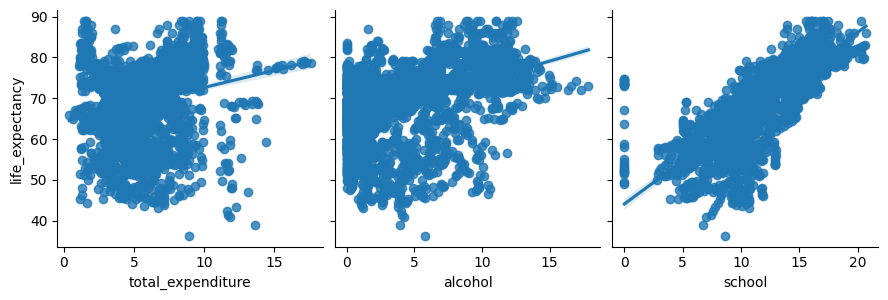

In [133]:
# Detecting outliers

get_pairs(df, target, features, 3)

## Identifying missing values

In [134]:
# View total rows per column

df.count()

,0
country,2938
life_expectancy,2928
year,2938
status,2938
adult_mortality,2928
inf_death,2938
alcohol,2744
hepatitisB,2385
measles,2938
bmi,2904


In [135]:
# Identifying the total missing values per column

missing_values = df.isnull().sum().sort_values(ascending = False)

In [136]:
print(missing_values)

population           652
hepatitisB           553
gdp                  448
total_expenditure    226
alcohol              194
school               163
bmi                   34
thinness_till19       34
thinness_till9        34
diphtheria            19
polio                 19
life_expectancy       10
adult_mortality       10
year                   0
country                0
measles                0
inf_death              0
status                 0
hiv                    0
dtype: int64


In [137]:
# Calculating the percentage of missing values

percent_missing_values = missing_values[missing_values > 0] / df.shape[0]

In [138]:
# Showing the percentage of missing values

(percent_missing_values * 100).round(2).astype(str) + "%"

,0
population,22.19%
hepatitisB,18.82%
gdp,15.25%
total_expenditure,7.69%
alcohol,6.6%
school,5.55%
bmi,1.16%
thinness_till19,1.16%
thinness_till9,1.16%
diphtheria,0.65%


## Identifying Outliers

First, we examine the variables with the highest percentage of missing values.

In [139]:
# Features with more than 5% of missing values

features = ['population', 'hepatitisB', 'gdp', 'total_expenditure', 'alcohol', 'school']

In [140]:
# New data frame with this features

new_df = df[features]

In [141]:
# Outlier detection using the IQR (Interquartile Range) method

Q1 = new_df.quantile(0.25)
Q3 = new_df.quantile(0.75)
IQR = Q3 - Q1

In [142]:
# Defining outliers as values that fall outside the interval. [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]

outliers = ((new_df < (Q1 - 1.5 * IQR)) | (new_df > (Q3 + 1.5 * IQR))).sum()

In [143]:
# Total of outliers per feature

outliers

,0
population,294
hepatitisB,254
gdp,365
total_expenditure,32
alcohol,0
school,44


In [144]:
# Outliers summary

outliers_summary = pd.DataFrame({
    'Outliers': outliers,
    'Percentage': ((outliers / len(new_df)) * 100).round(2)
})

In [145]:
# Results when there are more than 0 outliers

outliers_summary[outliers_summary['Outliers'] > 0]

,Outliers,Percentage
population,294,10.01
hepatitisB,254,8.65
gdp,365,12.42
total_expenditure,32,1.09
school,44,1.50


## Statistical analysis for outlier treatment

In [146]:
# Defining thresholds for outlier filtering

# Following common practice, we used a multiplier of 1.5, which may vary depending on the context and data distribution

inf_lim = Q1 - 1.5 * IQR
sup_lim = Q3 + 1.5 * IQR

In [147]:
# filtering outliers

new_df2 = df[~((new_df < inf_lim) | (new_df > sup_lim)).any(axis=1)]

In [148]:
# Shape

new_df2.shape

(2044, 19)

In [149]:
# New statistical summary

new_df2.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2036.000000,2044.000000,2036.000000,2044.000000,1908.000000,1653.000000,2044.000000,2032.000000,2041.000000,2041.000000,2044.000000,1668.000000,1883.000000,2032.000000,2032.000000,1910.000000,1.550000e+03
mean,68.261444,2007.516634,173.697937,21.272016,4.250854,88.543860,2043.051859,37.229429,83.469868,84.229789,1.906115,2603.414714,5.817047,4.973327,5.039813,11.779791,2.862564e+06
std,9.180601,4.620838,124.821601,75.877341,3.821064,11.667147,11166.996177,19.540099,22.293545,20.802376,5.353430,3051.987902,2.167468,4.070398,4.188165,2.893174,4.147575e+06
min,36.300000,2000.000000,1.000000,0.000000,0.010000,47.000000,0.000000,1.000000,3.000000,3.000000,0.100000,3.685949,0.370000,0.100000,0.100000,3.800000,3.400000e+01
25%,62.475000,2003.000000,83.750000,0.000000,0.847500,84.000000,0.000000,19.200000,78.000000,81.000000,0.100000,387.645945,4.380000,1.900000,1.900000,10.100000,1.413295e+05
50%,71.400000,2008.000000,154.000000,3.000000,3.400000,93.000000,10.000000,41.300000,93.000000,93.000000,0.100000,1312.038142,5.710000,3.550000,3.600000,12.100000,8.968025e+05
75%,74.700000,2012.000000,235.000000,17.000000,6.725000,97.000000,256.250000,54.900000,97.000000,97.000000,1.000000,3936.450613,7.130000,7.325000,7.400000,13.700000,3.712494e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.310000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.300000,13893.187680,12.250000,27.700000,28.600000,20.400000,1.789956e+07


In [150]:
# New maximum value for the population

new_df2.population.max()

17899562.0

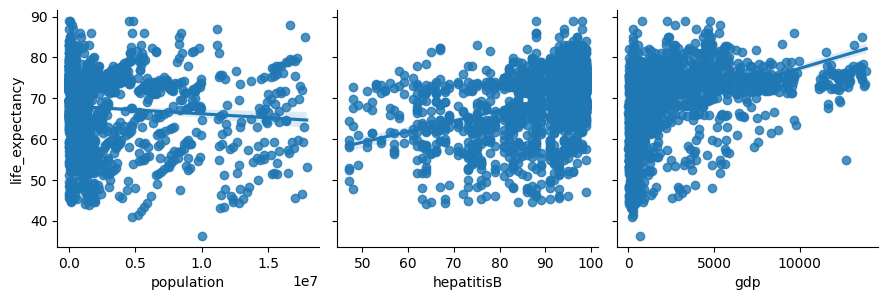

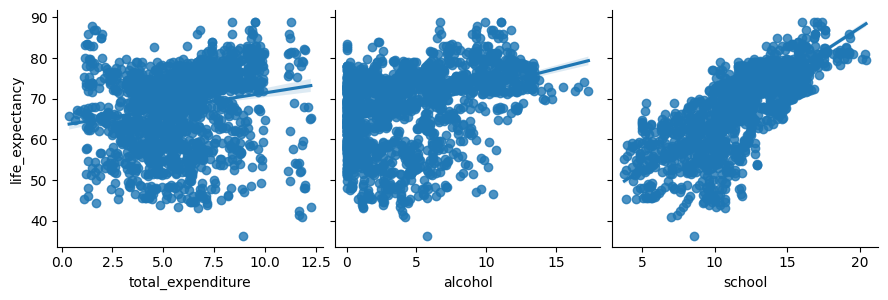

In [151]:
# Checking outliers again

get_pairs(new_df2, target, features, 3)

## Missing values: statistical analysis for treatment

In [152]:
# Checking the total number of missing values
missing_values = new_df2.isnull().sum().sort_values(ascending = False)

In [153]:
# Checking the percentage of missing values

missing_values_percent = missing_values[missing_values > 0] / new_df2.shape[0]
print(f'{missing_values_percent * 100} %')

population           24.168297
hepatitisB           19.129159
gdp                  18.395303
total_expenditure     7.876712
alcohol               6.653620
school                6.555773
bmi                   0.587084
thinness_till19       0.587084
thinness_till9        0.587084
life_expectancy       0.391389
adult_mortality       0.391389
diphtheria            0.146771
polio                 0.146771
dtype: float64 %


In [154]:
# Function to replace missing values using the median

def impute_median(data):
    return data.fillna(data.median())

In [155]:
new_df2.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2036.000000,2044.000000,2036.000000,2044.000000,1908.000000,1653.000000,2044.000000,2032.000000,2041.000000,2041.000000,2044.000000,1668.000000,1883.000000,2032.000000,2032.000000,1910.000000,1.550000e+03
mean,68.261444,2007.516634,173.697937,21.272016,4.250854,88.543860,2043.051859,37.229429,83.469868,84.229789,1.906115,2603.414714,5.817047,4.973327,5.039813,11.779791,2.862564e+06
std,9.180601,4.620838,124.821601,75.877341,3.821064,11.667147,11166.996177,19.540099,22.293545,20.802376,5.353430,3051.987902,2.167468,4.070398,4.188165,2.893174,4.147575e+06
min,36.300000,2000.000000,1.000000,0.000000,0.010000,47.000000,0.000000,1.000000,3.000000,3.000000,0.100000,3.685949,0.370000,0.100000,0.100000,3.800000,3.400000e+01
25%,62.475000,2003.000000,83.750000,0.000000,0.847500,84.000000,0.000000,19.200000,78.000000,81.000000,0.100000,387.645945,4.380000,1.900000,1.900000,10.100000,1.413295e+05
50%,71.400000,2008.000000,154.000000,3.000000,3.400000,93.000000,10.000000,41.300000,93.000000,93.000000,0.100000,1312.038142,5.710000,3.550000,3.600000,12.100000,8.968025e+05
75%,74.700000,2012.000000,235.000000,17.000000,6.725000,97.000000,256.250000,54.900000,97.000000,97.000000,1.000000,3936.450613,7.130000,7.325000,7.400000,13.700000,3.712494e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.310000,99.000000,212183.000000,87.300000,99.000000,99.000000,50.300000,13893.187680,12.250000,27.700000,28.600000,20.400000,1.789956e+07


In [156]:
# Removing missing values using different methods in some features

new_df2.loc[:,'population'] = new_df2['population'].transform(impute_median)
new_df2.hepatitisB = new_df2['hepatitisB'].transform(impute_median)
new_df2.alcohol = new_df2['alcohol'].transform(impute_median)
new_df2.total_expenditure = new_df2['total_expenditure'].transform(impute_median)
new_df2.gdp = new_df2['gdp'].transform(impute_median)
new_df2.school = new_df2['school'].transform(impute_median)

In [157]:
# Checking the total number of missing values

missing_values = new_df2.isnull().sum().sort_values(ascending = False)

In [158]:
# Checking remaining missing values

missing_values_percent = missing_values[missing_values > 0] / new_df2.shape[0]
print(f'{missing_values_percent * 100} %')

thinness_till19    0.587084
thinness_till9     0.587084
bmi                0.587084
life_expectancy    0.391389
adult_mortality    0.391389
polio              0.146771
diphtheria         0.146771
dtype: float64 %


In [159]:
# Now we can remoe the missing values

new_df2.dropna(inplace = True)

In [160]:
# Checking again the number of missing values

missing_values = new_df2.isnull().sum().sort_values(ascending = False)

In [161]:
# Checking missing values percentage

missing_values_percent = missing_values[missing_values > 0] / new_df2.shape[0]
print(f'{missing_values_percent * 100} %')

Series([], dtype: float64) %


In [162]:
# Shape

new_df2.shape

(2023, 19)

In [163]:
new_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2023 entries, 1 to 2937
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            2023 non-null   object 
 1   life_expectancy    2023 non-null   float64
 2   year               2023 non-null   int64  
 3   status             2023 non-null   object 
 4   adult_mortality    2023 non-null   float64
 5   inf_death          2023 non-null   int64  
 6   alcohol            2023 non-null   float64
 7   hepatitisB         2023 non-null   float64
 8   measles            2023 non-null   int64  
 9   bmi                2023 non-null   float64
 10  polio              2023 non-null   float64
 11  diphtheria         2023 non-null   float64
 12  hiv                2023 non-null   float64
 13  gdp                2023 non-null   float64
 14  total_expenditure  2023 non-null   float64
 15  thinness_till19    2023 non-null   float64
 16  thinness_till9     2023 non-n

 We are going to use socioeconomic indicador regardless the country identification. Let's remove the categoric variables.

In [164]:
# Drop the variables

new_df2.drop(['country', 'status'], axis = 1, inplace = True)

In [165]:
# Original dataset shape

df.shape

(2938, 19)

In [166]:
# Datasaet shape after cleaning

new_df2.shape

(2023, 17)

## Feature Engineering

The large disparity in population sizes across countries makes the direct use of this variable potentially problematic. To address this, we transform population into a categorical feature with three distinct population levels.

In [167]:
new_df2.head()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
1,59.9,2014,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0
3,59.5,2012,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0
4,59.2,2011,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0
5,58.8,2010,279.0,74,0.01,66.0,1989,16.7,66.0,66.0,0.1,553.328940,9.20,18.4,18.4,9.2,2883167.0
6,58.6,2009,281.0,77,0.01,63.0,2861,16.2,63.0,63.0,0.1,445.893298,9.42,18.6,18.7,8.9,284331.0


In [168]:
new_df2.population.min()

34.0

In [169]:
new_df2.population.max()

17899562.0

In [170]:
#  We must develop cuttoffs with 2 percentile as reference
cutoffs = [new_df2.population.quantile(0.33), new_df2.population.quantile(0.67)]

In [171]:
cutoffs

[np.float64(656519.86), np.float64(1365811.6)]

In [172]:
# We introduced a new feature, with all observations assigned a value of 1.

new_df2['pop_size'] = 1

In [173]:
# We defined the tier corresponding to a feature value of 2.

new_df2.loc[(new_df2.population < cutoffs[1]) & (new_df2.population > cutoffs[0]), 'pop_size'] = 2

In [174]:
# We defined the tier corresponding to a feature value of 3.

new_df2.loc[new_df2.population >= cutoffs[1], 'pop_size'] = 3

In [175]:
# New Dataset
new_df2.head()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size
1,59.9,2014,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0,1
3,59.5,2012,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0,3
4,59.2,2011,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0,3
5,58.8,2010,279.0,74,0.01,66.0,1989,16.7,66.0,66.0,0.1,553.328940,9.20,18.4,18.4,9.2,2883167.0,3
6,58.6,2009,281.0,77,0.01,63.0,2861,16.2,63.0,63.0,0.1,445.893298,9.42,18.6,18.7,8.9,284331.0,1


In [176]:
# pop_size value counts

new_df2.pop_size.value_counts()

,count
pop_size,
2,687
1,668
3,668


The features alcohol and BMI are directly related. We therefore create a new feature, life_style, by combining both variables.

In [177]:
# Criando a nova variável  Creating a new feature
new_df2['lifestyle'] = 0
new_df2.lifestyle = new_df2['bmi'] * new_df2['alcohol']

In [178]:
new_df2.head()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
1,59.9,2014,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0,1,0.186
3,59.5,2012,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0,3,0.176
4,59.2,2011,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0,3,0.172
5,58.8,2010,279.0,74,0.01,66.0,1989,16.7,66.0,66.0,0.1,553.328940,9.20,18.4,18.4,9.2,2883167.0,3,0.167
6,58.6,2009,281.0,77,0.01,63.0,2861,16.2,63.0,63.0,0.1,445.893298,9.42,18.6,18.7,8.9,284331.0,1,0.162


In [179]:
new_df2.lifestyle.describe()

,lifestyle
count,2023.000000
mean,178.996408
std,209.416553
min,0.018000
25%,18.140500
50%,95.323000
75%,257.394000
max,1036.869000


In [180]:
# Checking if there's missing values
missing_values = new_df2.isnull().sum().sort_values(ascending = False)
missing_values

,0
life_expectancy,0
year,0
adult_mortality,0
inf_death,0
alcohol,0
hepatitisB,0
measles,0
bmi,0
polio,0
diphtheria,0


In [181]:
new_df2.dtypes

,0
life_expectancy,float64
year,int64
adult_mortality,float64
inf_death,int64
alcohol,float64
hepatitisB,float64
measles,int64
bmi,float64
polio,float64
diphtheria,float64


## Correlation analysis to assess multicollinearity

Ideally, predictor variables should be highly correlated with the target variable but not with each other. High correlation among predictors, referred to as multicollinearity, negatively affects regression models by increasing coefficient instability and reducing interpretability.

Correlation is a metric that measures the strength and direction of the relationship between variables. The correlation coefficient ranges from -1 to +1, where:

**−1 represents a strong negative correlation.**

**+1 represents a strong positive correlation.**

**0 means no linear relationship.**

In [182]:
# Correlation among numerical variables in the transformed dataset

new_df2.corr()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
life_expectancy,1.000000,0.204556,-0.658916,-0.206443,0.342425,0.257860,-0.115350,0.557954,0.452564,0.483659,-0.573127,0.360736,0.175738,-0.433580,-0.429357,0.708272,-0.105317,-0.117333,0.441366
year,0.204556,1.000000,-0.091760,-0.059838,-0.066639,-0.003178,-0.064347,0.096763,0.147489,0.228939,-0.158820,0.170945,0.070267,-0.059353,-0.055950,0.219471,0.020981,0.013190,-0.017373
adult_mortality,-0.658916,-0.091760,1.000000,0.099370,-0.149204,-0.188950,0.035432,-0.366745,-0.228938,-0.221803,0.512978,-0.197863,-0.090963,0.299104,0.302507,-0.383901,0.096768,0.123785,-0.231128
inf_death,-0.206443,-0.059838,0.099370,1.000000,-0.127545,-0.122515,0.480129,-0.221948,-0.183569,-0.183910,0.039115,-0.120331,-0.121871,0.321487,0.354512,-0.214215,0.111901,0.111776,-0.156769
alcohol,0.342425,-0.066639,-0.149204,-0.127545,1.000000,0.193844,-0.045324,0.310448,0.187916,0.199958,-0.036268,0.289360,0.262657,-0.386629,-0.379482,0.464657,-0.007040,0.002445,0.878858
hepatitisB,0.257860,-0.003178,-0.188950,-0.122515,0.193844,1.000000,-0.043089,0.115409,0.393191,0.391270,-0.090390,0.167829,0.046093,-0.086406,-0.102546,0.263879,-0.056455,-0.028477,0.181579
measles,-0.115350,-0.064347,0.035432,0.480129,-0.045324,-0.043089,1.000000,-0.142187,-0.110853,-0.123043,0.024412,-0.065666,-0.101675,0.133515,0.137056,-0.089084,-0.005326,0.017013,-0.085123
bmi,0.557954,0.096763,-0.366745,-0.221948,0.310448,0.115409,-0.142187,1.000000,0.253961,0.273612,-0.244626,0.323198,0.200959,-0.541904,-0.550691,0.552766,-0.056945,-0.041854,0.599062
polio,0.452564,0.147489,-0.228938,-0.183569,0.187916,0.393191,-0.110853,0.253961,1.000000,0.676507,-0.143756,0.198453,0.141294,-0.166819,-0.166363,0.382712,-0.045542,-0.041742,0.219793
diphtheria,0.483659,0.228939,-0.221803,-0.183910,0.199958,0.391270,-0.123043,0.273612,0.676507,1.000000,-0.154179,0.222266,0.157976,-0.189487,-0.186992,0.430627,-0.035142,-0.035290,0.225132


In [183]:
# Filtering the correlation matrix

dfCorr = new_df2.corr()
df_filter_1 = dfCorr[((dfCorr >= 0.3) | (dfCorr <= -0.3)) & (dfCorr != 1.000)]
df_filter_1

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
life_expectancy,NaN,NaN,-0.658916,NaN,0.342425,NaN,NaN,0.557954,0.452564,0.483659,-0.573127,0.360736,NaN,-0.433580,-0.429357,0.708272,NaN,NaN,0.441366
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,-0.658916,NaN,NaN,NaN,NaN,NaN,NaN,-0.366745,NaN,NaN,0.512978,NaN,NaN,NaN,0.302507,-0.383901,NaN,NaN,NaN
inf_death,NaN,NaN,NaN,NaN,NaN,NaN,0.480129,NaN,NaN,NaN,NaN,NaN,NaN,0.321487,0.354512,NaN,NaN,NaN,NaN
alcohol,0.342425,NaN,NaN,NaN,NaN,NaN,NaN,0.310448,NaN,NaN,NaN,NaN,NaN,-0.386629,-0.379482,0.464657,NaN,NaN,0.878858
hepatitisB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.393191,0.391270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,0.480129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,0.557954,NaN,-0.366745,NaN,0.310448,NaN,NaN,NaN,NaN,NaN,NaN,0.323198,NaN,-0.541904,-0.550691,0.552766,NaN,NaN,0.599062
polio,0.452564,NaN,NaN,NaN,NaN,0.393191,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,0.382712,NaN,NaN,NaN
diphtheria,0.483659,NaN,NaN,NaN,NaN,0.391270,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,0.430627,NaN,NaN,NaN


The variables adult_mortality, alcohol, BMI, polio, diphtheria, HIV, GDP, thinness_till19, thinness_till9, school, and life_style meet our selection criteria. They are the predictor variables with the highest correlation with the target feature.

Next, we check one of the assumptions of linear regression and identify potential multicollinearity issues, i.e., high correlation among predictor variables. Based on this criterion, one of two highly correlated predictors is removed. A correlation threshold of 0.65 is applied, and the correlation matrix is filtered accordingly.

In [200]:
# Filtering the matrix correlation
dfCorr = new_df2.corr()
df_filter_2 = dfCorr[((dfCorr >= 0.65) | (dfCorr <= -0.65)) & (dfCorr != 1.000)]
df_filter_2 = df_filter_2.drop('life_expectancy', axis=1)
df_filter_2 = df_filter_2.drop('life_expectancy', axis=0)
df_filter_2

,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inf_death,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.878858
hepatitisB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
polio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diphtheria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hiv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can observe the high correlation among some of the predictor variables

### Decision

**1st Filter – Correlation with the Target Variable**

The variables adult_mortality, alcohol, bmi, polio, diphtheria, hiv, gdp, thinness_till19, thinness_till9, school, and lifestyle meet our first criterion. These are the predictor variables with the highest correlation with the target variable.

**2nd Filter – Multicollinearity**

Based on the multicollinearity filter, the variables adult_mortality, diphtheria, hiv, gdp, thinness_till19, school, and lifestyle are retained for statistical modeling.

**3rd Filter – Data Understanding, Business Context, and Result Delivery**

Although the variable bmi shows a higher correlation with the target variable than lifestyle, the latter encapsulates information from two variables (alcohol and bmi). For this reason, we discard bmi and retain lifestyle. This choice also helps reduce potential multicollinearity between the two variables and improves the interpretability of the results for decision-makers.

Note: Retaining bmi instead of lifestyle is also a valid choice. We tested this alternative, and the statistical modeling led to the same conclusions.

In [204]:
# Preparing the New Dataset
new_df2_final = pd.DataFrame({'life_expectancy': new_df2['life_expectancy'],
                              'adult_mortality': new_df2['adult_mortality'],
                              'diphtheria': new_df2['diphtheria'],
                              'hiv': new_df2['hiv'],
                              'gdp': new_df2['gdp'],
                              'thinness_till19': new_df2['thinness_till19'],
                              'school': new_df2['school'],
                              'lifestyle': new_df2['lifestyle'],})

In [205]:
new_df2_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
5,58.8,279.0,66.0,0.1,553.328940,18.4,9.2,0.167
6,58.6,281.0,63.0,0.1,445.893298,18.6,8.9,0.162


In [206]:
# Check for Missing Values
missing_values = new_df2_final.isnull().sum().sort_values(ascending = False)
missing_values

,0
life_expectancy,0
adult_mortality,0
diphtheria,0
hiv,0
gdp,0
thinness_till19,0
school,0
lifestyle,0


In [208]:
# Visualizing the Number of Observations per Column
new_df2_final.count()

,0
life_expectancy,2023
adult_mortality,2023
diphtheria,2023
hiv,2023
gdp,2023
thinness_till19,2023
school,2023
lifestyle,2023


In [209]:
# Checking multicoliearity and removing the highly correlated variables

corr_map = new_df2_final.corr()
corr_map

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
life_expectancy,1.000000,-0.658916,0.483659,-0.573127,0.360736,-0.433580,0.708272,0.441366
adult_mortality,-0.658916,1.000000,-0.221803,0.512978,-0.197863,0.299104,-0.383901,-0.231128
diphtheria,0.483659,-0.221803,1.000000,-0.154179,0.222266,-0.189487,0.430627,0.225132
hiv,-0.573127,0.512978,-0.154179,1.000000,-0.118378,0.212890,-0.232993,-0.132152
gdp,0.360736,-0.197863,0.222266,-0.118378,1.000000,-0.211979,0.460247,0.333733
thinness_till19,-0.433580,0.299104,-0.189487,0.212890,-0.211979,1.000000,-0.424922,-0.449094
school,0.708272,-0.383901,0.430627,-0.232993,0.460247,-0.424922,1.000000,0.528939
lifestyle,0.441366,-0.231128,0.225132,-0.132152,0.333733,-0.449094,0.528939,1.000000


In [210]:
# Function to plot the correlation matrix
def CorrMat(df, dropDuplicates = True, xrot = 70, yrot = 0, label = 'Variable'):

    # Remove duplicate correlations by masking the upper-right values
    if dropDuplicates:
        mask = np.zeros_like(df, dtype = bool)
        mask[np.triu_indices_from(mask)] = True

    # Set background color / plot style
    sns.set_style(style = 'dark')
    fig, ax = plt.subplots(figsize = (8, 8))

    # Add color map from red to blue
    plt.title("Correlation Matrix")

    # Draw correlation plot with or without duplicates
    if dropDuplicates:
        sns.heatmap(df, mask = mask, square = True, linewidth = .5, cbar_kws = {"shrink": .5}, ax = ax)
        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation=xrot)
        plt.yticks(rotation=yrot)

    else:
        sns.heatmap(df, square = True, linewidth = .5, cbar_kws = {"shrink": .5}, ax = ax)
        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation = xrot)
        plt.yticks(rotation = yrot)
    return

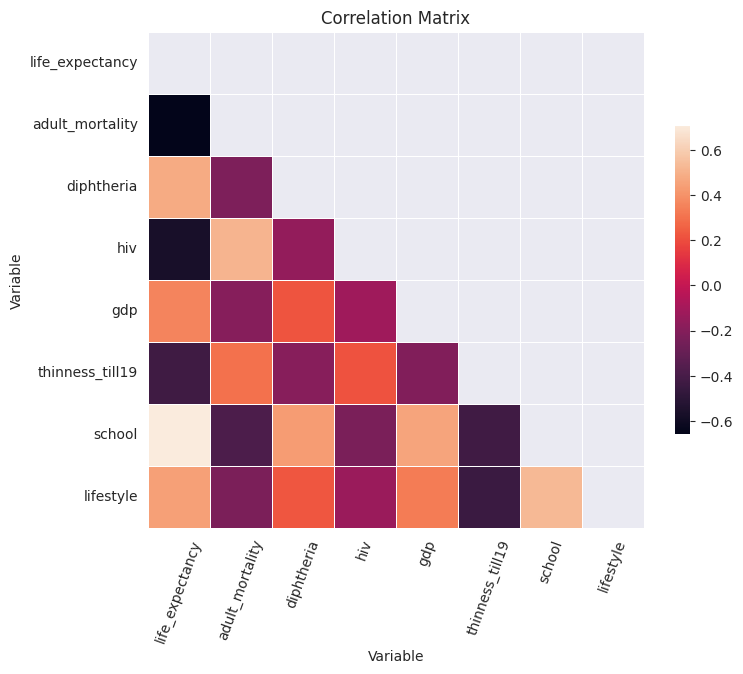

In [211]:
# Plot da matriz de correlação correlation matrix plot
CorrMat(corr_map)

In [212]:
# Dataset
new_df2_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
5,58.8,279.0,66.0,0.1,553.328940,18.4,9.2,0.167
6,58.6,281.0,63.0,0.1,445.893298,18.6,8.9,0.162


In [213]:
# Dataset
new_df2_final.dtypes

,0
life_expectancy,float64
adult_mortality,float64
diphtheria,float64
hiv,float64
gdp,float64
thinness_till19,float64
school,float64
lifestyle,float64


In [195]:
new_df2_final.shape

(2023, 8)

### Statistical Modeling


In [214]:
# Target variable x Predictor variables
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + gdp + thinness_till19 + school + lifestyle'

In [215]:
# Cria e treina o modelo Create and train the model
model_1 = ols(formula, data = new_df2_final).fit()

In [216]:
# Model Performance – Coefficient of Determination (R²)
print(f"R-squared: {model_1}")

R-squared: <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x7c0c9fa492e0>


In [217]:
# Coefficients
print(f"Coefficients:\n{model_1.params}")

Coefficients:
Intercept          51.016574
adult_mortality    -0.021286
diphtheria          0.079267
hiv                -0.484974
gdp                 0.000062
thinness_till19    -0.127453
school              1.289512
lifestyle           0.002567
dtype: float64


In [218]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     984.6
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:10:39   Log-Likelihood:                -5852.1
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2015   BIC:                         1.177e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          51.0166      0.667     76.474      0.000      49.708      52.325
adult_mortality    -0.0213      0.001    -22.068      0.000      -0.023      -0.019
diphtheria          0.0793      0.005     15.252      0.000       0.069       0.089
hiv                -0.4850      0.021    -22.928      0.000      -0.526      -0.443
gdp              6.181e-05   3.93e-05      1.574      0.116   -1.52e-05       0.000
thinness_till19    -0.1275      0.028     -4.546      0.000      -0.182      -0.072
school              1.2895      0.049     26.065      0.000       1.192       1.387
lifestyle           0.0026      0.001      4.451      0.000       0.001       0.004
==============================================================================
Omnibus:                      105.060   Durbin-Watson:                   0.675
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              194.134
Skew:                          -0.383   Prob(JB):                     6.99e-43
Kurtosis:                       4.310   Cond. No.                     2.53e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.53e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> The variable gdp has a p-value above 0.05 and is therefore not statistically significant for explaining the target variable. Consequently, it will be removed from the model.

In [219]:
# 2nd Regression model version
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + thinness_till19 + school + lifestyle'
model_2 = ols(formula, data = new_df2_final).fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1147.
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:11:15   Log-Likelihood:                -5853.3
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2016   BIC:                         1.176e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          50.8445      0.658     77.233      0.000      49.553      52.136
adult_mortality    -0.0213      0.001    -22.094      0.000      -0.023      -0.019
diphtheria          0.0795      0.005     15.299      0.000       0.069       0.090
hiv                -0.4850      0.021    -22.922      0.000      -0.527      -0.444
thinness_till19    -0.1266      0.028     -4.515      0.000      -0.182      -0.072
school              1.3132      0.047     27.859      0.000       1.221       1.406
lifestyle           0.0027      0.001      4.671      0.000       0.002       0.004
==============================================================================
Omnibus:                      108.281   Durbin-Watson:                   0.676
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.828
Skew:                          -0.394   Prob(JB):                     4.05e-44
Kurtosis:                       4.323   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

See note 2 above. There appears to be multicollinearity among the predictors.
We can revisit our decision criteria and remove variables with correlation above 0.55, for example (instead of the 0.65 threshold used previously).
Before doing so, we will standardize the data, put everything on the same scale, and evaluate the results.

In [220]:
# features that are goind to be standardize
features = ['adult_mortality', 'diphtheria', 'hiv', 'thinness_till19', 'school', 'lifestyle']

In [221]:
# Standardize

scaler = StandardScaler()
scaler.fit(new_df2_final[features])
scaled_features = scaler.transform(new_df2_final[features])

In [222]:
# Dataframe with standardized data

scaled_features_df = pd.DataFrame(scaled_features, columns = features, index = new_df2_final.index)
scaled_features_df.head()

,adult_mortality,diphtheria,hiv,thinness_till19,school,lifestyle
1,0.784288,-1.070929,-0.337999,3.076510,-0.658477,-0.854062
3,0.792299,-0.830592,-0.337999,3.174831,-0.730539,-0.854109
4,0.816331,-0.782525,-0.337999,3.248572,-0.838631,-0.854128
5,0.848374,-0.878660,-0.337999,3.297732,-0.946724,-0.854152
6,0.864395,-1.022861,-0.337999,3.346893,-1.054817,-0.854176


In [223]:
# Third version model

model_v3 = sm.OLS(endog = new_df2_final['life_expectancy'],
                   exog = sm.add_constant(scaled_features_df.values)).fit()

In [224]:
model_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1147.
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:24:50   Log-Likelihood:                -5853.3
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2016   BIC:                         1.176e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.3059      0.097    702.041      0.000      68.115      68.497
x1            -2.6608      0.120    -22.094      0.000      -2.897      -2.425
x2             1.6541      0.108     15.299      0.000       1.442       1.866
x3            -2.6080      0.114    -22.922      0.000      -2.831      -2.385
x4            -0.5151      0.114     -4.515      0.000      -0.739      -0.291
x5             3.6447      0.131     27.859      0.000       3.388       3.901
x6             0.5602      0.120      4.671      0.000       0.325       0.795
==============================================================================
Omnibus:                      108.281   Durbin-Watson:                   0.676
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.828
Skew:                          -0.394   Prob(JB):                     4.05e-44
Kurtosis:                       4.323   Cond. No.                         2.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Delivering the Results to the Decision Maker

**Summary of the Life Expectancy Analysis**

Our analysis used a statistical model to examine how various factors influence life expectancy. The results provide valuable insights that can guide public health strategies and resource allocation.

Key Findings:

Model Effectiveness: The model proved to be highly effective, explaining approximately 77% of the variation in life expectancy. This indicates a high degree of accuracy in our ability to predict life expectancy based on the factors analyzed.

Impact of Health and Lifestyle Factors:

Adult Mortality and HIV: As expected, increases in adult mortality and HIV rates are significantly associated with decreases in life expectancy. These results emphasize the need to continue and strengthen health programs focused on reducing mortality and combating HIV.

Education and Healthy Lifestyle: Conversely, positive factors such as higher education levels and a healthy lifestyle show a strong association with increased life expectancy. This reinforces the importance of investing in education and promoting healthy lifestyles as integral components of public health policy.

Vaccination and Nutrition: The analysis also highlighted the importance of vaccination (e.g., against diphtheria) and good nutrition (indicated by lower prevalence of thinness among children and adolescents) as key factors in improving life expectancy.

Recommendations:

Focus on Prevention: Strengthen prevention and treatment programs for critical diseases such as HIV and improve vaccination coverage.

Health Education: Invest in education as a means to promote healthy lifestyles and improve population health indicators.

Monitoring and Evaluation: Continue to monitor these health factors and adjust public policies as needed to address emerging population needs.

Conclusion:

This study reaffirms the importance of not only combating diseases but also promoting education and healthy lifestyles. The findings provide a solid foundation for informed decisions that can lead to significant improvements in population health and longevity.
